In [37]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import gymnasium as gym

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from libraries import fdrl26_fl as fl
from libraries import fdrl26_rl as rl

1. Створіть власну карту FrozenLake розміром $N \times N$,  $5 \le N \le 9$. Розмістіть початкову клітинку, ціль і щонайменше 4 ополонки. Переконайтеся, що від старту до цілі існує маршрут. Створіть середовище з увімкненим ковзанням (`is_slippery=True`) і зобразіть карту з номерами станів.

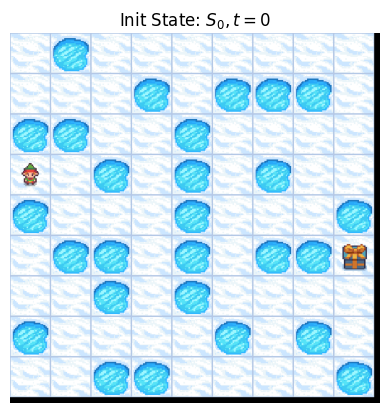

In [38]:
map = [
    "FHFFFFFFF",
    "FFFHFHHHF",
    "HHFFHFFFF",
    "SFHFHFHFF",
    "HFFFHFFFH",
    "FHHFHFHHG",
    "FFHFHFFFF",
    "HFFFFHFHF",
    "FFHHFFFFH"
]

env = gym.make(
    "FrozenLake-v1",
    is_slippery = True,
    desc = map,
    max_episode_steps=400,
    render_mode="rgb_array"
)

nS = env.observation_space.n
nA = env.action_space.n
action_symbols = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}
action_arrows  = {0: '←', 1: '↓', 2: '→', 3: '↑'}

N = len(map)

state, info = env.reset()
pic=env.render()
plt.imshow(pic)
plt.title("Init State: $S_0,  t=0$")
plt.axis('off')

plt.savefig("../data/FL_initstate.png", bbox_inches="tight")
plt.show()

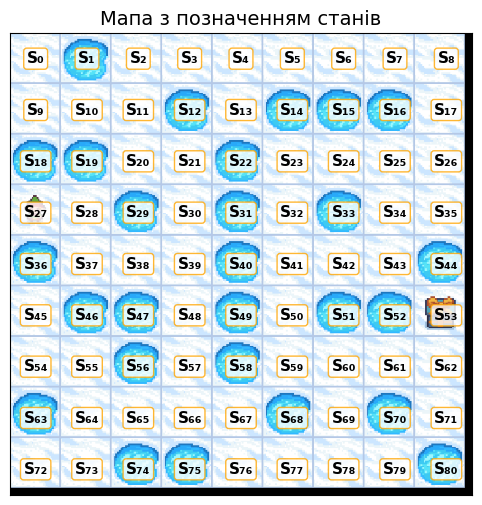

In [39]:
def to_subscript(n):
    sub_digits = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return str(n).translate(sub_digits)

img = env.render()
rows, cols = len(map), len(map[0])

plt.figure(figsize=(10, 6))
plt.imshow(img)

plt.xticks([])
plt.yticks([])

height, width, _ = img.shape
cell_h = height / rows
cell_w = width / cols

for r in range(rows):
    for c in range(cols):
        state_idx = r * cols + c
        x = (c + 0.5) * cell_w
        y = (r + 0.5) * cell_h
        state_str = f"S{to_subscript(state_idx)}"
        
        plt.text(x, y, state_str, color='black', fontsize=11, 
                 fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='orange'))

plt.xlim(0, width)
plt.ylim(height, 0)

plt.title(f"Мапа з позначенням станів", fontsize=14)
plt.show()

2. Дослідіть правила переходів. Поясніть, чому вибрана дія не завжди приводить агента до сусідньої клітинки у вибраному напрямку.

Так як параметр `is_slippery` встановлено на True, то це додає стохастичну поведінку до руху. Агент обирає напрямок руху, але цей параметр додає вірогідність, що напрямок зміниться і персонаж посунеться в іншому напрямку

3. Задайте дві політики для всіх нетермінальних станів: рівноймовірний вибір дій та власну детерміновану політику, спрямовану на досягнення цілі. Позначте дії детермінованої політики на карті. На цьому етапі не потрібно доводити, що вона оптимальна.

In [40]:
sym = [
    "D . R R R R R R D",
    "R R U . U . . . D",
    ". . U L . D L D L",
    ". D . U . D . D L",
    ". R R D . D L L .",
    "D . . D . D . . .",
    "R D . D . R R R U",
    ". R R R D . U . U",
    "R U . . R R U L ."
]

det = fl.policy_symbolic_to_deterministic(sym)
policy1 = rl.policy_deterministic_to_stochastic(det_policy=det, nA=len(action_symbols), epsilon=1)
policy2 = rl.policy_deterministic_to_stochastic(det_policy=det, nA=len(action_symbols), epsilon=0)